# Credit Portfolio Optimization: Growth vs. Risk Analysis
### Strategic Decision-Making Framework via Logistic Regression

---

## 1. Executive Summary & Objective
In credit risk management, maximizing financial returns requires balancing two competing forces: **Portfolio Growth** (maximizing loan approvals to drive revenue) and **Risk Mitigation** (restricting approvals to minimize defaults and capital losses). Setting the credit decision threshold too high chokes revenue, while setting it too low invites catastrophic default rates.

This notebook builds a strategic decision framework using our previously trained and exceptionally calibrated **Logistic Regression model** (Brier Score: ~0.09). Because our model's output scores reflect true real-world probabilities, we can confidently translate these machine learning risk scores into expected financial metrics to find the optimal operational sweet spot.

### Key Objectives:
* **The Growth-Risk Frontier:** Map how varying the credit approval probability threshold impacts total loan volume versus total realized defaults.
* **Financial Impact Modeling:** Quantify the trade-offs by assigning real-world dollar values to approvals (interest revenue generated) and defaults (principal capital lost).
* **Optimal Cut-off Selection:** Determine the mathematically precise probability threshold that maximizes net portfolio profitability based on the institution's specific risk appetite.

## 1. Initial Data Loading & Environmental Setup
In this initial step, we load the raw loan performance dataset into a Pandas DataFrame. 

In [ ]:
import kagglehub
import pandas
import glob
import os

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")
# Joins the folder path with the wildcard pattern
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("Path to dataset files:", path)
print(csv_files)

df = pandas.read_csv(csv_files[0])
categorical_columns = (df.select_dtypes(include=['str']) if pandas.__version__[0] >= '3' else df.select_dtypes(include=['object'])).columns[1:].tolist()
print(categorical_columns)
df

['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


## 2. Data Splitting: Train, Validation, and Test Sets
In this step, we partition our dataset into three distinct subsets—**Training (70%)**, **Validation (10%)**, and **Test (20%)**—using a **stratified split**. 

* **Training Set:** Used exclusively to fit our Logistic Regression model and calculate the stratified WoE/probability mappings.
* **Validation Set:** Used to tune hyperparameters (such as the regularization strength parameter, $C$) and prevent overfitting.
* **Test Set:** Held back as a final "blind" dataset to evaluate how well our model generalizes to completely unseen credit applications.

*Note: We apply **stratification** based on our target variable to ensure that the 11% default rate is precisely preserved across all three data subsets.*

In [2]:
from sklearn.model_selection import train_test_split


df['stratify_col'] = df[categorical_columns].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)

train_val_df_raw, test_df_raw = train_test_split(
    df, 
    test_size=0.20, 
    random_state=100, 
    stratify=df['stratify_col'] + '_' + df['Default'].astype(str) # <--- Stratifying on combined column
)

train_df_raw, val_df_raw = train_test_split(
    train_val_df_raw, 
    test_size=0.20, 
    random_state=100, 
    stratify=train_val_df_raw['stratify_col'] + '_' + train_val_df_raw['Default'].astype(str) # <--- Stratifying on combined column
)
del train_val_df_raw

print(f'Checking stratification: {train_df_raw["stratify_col"].unique().shape[0]} unique values in train set, {test_df_raw["stratify_col"].unique().shape[0]} unique values in test set')
print(f'Train size: {train_df_raw.shape[0]}, Validation size: {val_df_raw.shape[0]}, Test size: {test_df_raw.shape[0]}')

Checking stratification: 1920 unique values in train set, 1920 unique values in test set
Train size: 163421, Validation size: 40856, Test size: 51070


In [11]:
train_df = train_df_raw.copy()
val_df = val_df_raw.copy()
test_df = test_df_raw.copy()

In [12]:
drop_cols = []

X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

## 3. Feature Engineering: Categorical-to-Numerical Transformation
In this section, we convert our **4 categorical variables** into highly predictive numerical features optimized for our Logistic Regression pipeline. This transformation ensures our models can interpret the categorical data while preserving complex non-linear relationships.

### Strategic Roadmap:
* **Stratified Combination:** Cross-tabulating individual categorical fields to create unique borrower strata.
* **Probability Mapping:** Converting the categorical strata into empirical probability-of-default features.
* **Weight of Evidence (WoE) Encoding:** Translating the categorical groups into numerical linear logs-odds scores to match the mathematical requirements of Logistic Regression.

## 3.1 Generating Weight of Evidence (WoE) Embedding Dictionaries
To apply our feature engineering strategy, we calculate the **Weight of Evidence (WoE)** values for our stratified categorical segments using the training partition. 

Instead of adding multiple structural columns to our dataframe right away, we store these calculated mappings inside a native **Python dictionary**. 

### Benefits of the Dictionary Mapping Approach:
* **Prevents Data Leakage:** Mappings are generated strictly from training data distributions and stored safely inside a reference dictionary object.
* **Lightweight & Fast:** The dictionary acts as a lookup table. We can instantly embed WoE values into the Train, Validation, and Test sets using a highly efficient `.map()` operation.
* **Production-Ready:** This dictionary format is highly portable and can easily be exported as a JSON file, making it simple to deploy into a live production scoring pipeline.

In [13]:
from utils import calculate_woe, woe_multiple
from utils import category_to_woe

woe_dict, iv_df = woe_multiple(train_df, ['stratify_col'], target='Default')

Total Information Value (IV) for 'stratify_col': 0.1358
Information Value Ranking:
                    IV
stratify_col  0.135782


## 3.2 Target Probability Encoding
In this step, we implement **Target Probability Encoding** on our stratified categorical fields. This technique replaces each categorical combination with its corresponding empirical probability of default ($P(\text{Default} | \text{Category})$) derived directly from the training data.

#### Implementation & Safeguards:
* **Linearizing Relationships:** This converts raw text categories into a continuous numerical range between $0$ and $1$, mapping a direct mathematical relationship to our target variable.
* **Leakage Prevention:** To avoid overfitting and data leakage, these probabilities are calculated strictly using the training partition. The resulting mapping matrix is then applied blindly as a lookup table to the validation and test datasets.

In [14]:
from statsmodels.stats.proportion import proportions_ztest

default_rate_by_all_categories = train_df.groupby('stratify_col')['Default'].agg(['mean', 'count']).sort_values('mean', ascending=False)
default_rate_by_all_categories['pval'] = default_rate_by_all_categories.apply(lambda row: proportions_ztest(count=[row['count'] * row['mean'],
                                                                                                                   train_df['Default'].mean() * train_df['Default'].count()],
                                                                                                                   nobs=[row['count'], train_df['Default'].count()],
                                                                                                                   alternative='two-sided')[1], axis=1)
default_rate_by_all_categories = default_rate_by_all_categories.rename(columns={'index': 'category_value', 'mean': 'default_rate', 'count': 'num_samples'})
default_rate_by_all_categories['significant'] = default_rate_by_all_categories['pval'] < 0.05
prob_dict = default_rate_by_all_categories[ 'default_rate'].to_dict()

### 3.3 Modular Pipeline: The `feature_engineering` Function
To ensure clean, reproducible, and production-ready code, we encapsulate our entire transformation logic into a single Python function. 

This modular function takes a raw dataset and our pre-calculated dictionary mappings (probabilities and WoE embeddings) as inputs, then applies the stratified transformations uniformly across the columns.

#### Key Engineering Benefits:
* **Consistency:** Applies identical mapping logic across Train, Validation, and Test sets, guaranteeing feature parity.
* **Leakage Prevention:** By feeding pre-computed dictionaries into the function, we ensure that validation and test data are never used during the initial encoding calculations.
* **Scalability:** Streamlines the deployment process, allowing the exact same data pipeline to process new, real-time loan applications in a production environment.

In [15]:
def feature_engineering(df, woe_dict, prob_dict):
    df = category_to_woe(df, ['stratify_col'], woe_dict)
    df['stratify_col_prob'] = df['stratify_col'].map(prob_dict)
    df = df.drop(columns=['LoanID', 'stratify_col'] + categorical_columns)
    return df

train_df = feature_engineering(train_df, woe_dict, prob_dict)
val_df = feature_engineering(val_df, woe_dict, prob_dict)
test_df = feature_engineering(test_df, woe_dict, prob_dict)

X_train = train_df.drop(columns=['Default'])
y_train = train_df['Default']
X_val = val_df.drop(columns=['Default'])
y_val = val_df['Default']
X_test = test_df.drop(columns=['Default'])
y_test = test_df['Default']

## 4 Model Retrieval: Loading the LogisticRegression Model from MLflow
Before initializing the post-processing calibration pipeline, we must retrieve our best-performing, uncalibrated LogisticRegression model directly from the **MLflow Artifact Store** or **Model Registry**. 

This programmatic retrieval ensures that we are calibrating the exact production-ready weights and feature tracking configurations logged during our previous training run.

In [16]:
# LogisticRegression_with_stratify_col_prob_scaled
import pickle

# Open the file in binary mode for reading
with open('C:/Users/victo/Downloads/firsthelp/notebooks/mlruns/1/models/m-5ce18f3dc030457b8bc518cee244979c/artifacts/model.pkl', 'rb') as f:
    final_model = pickle.load(f)

## 5 Threshold Scanning & Decision Optimization

### 5.1 Threshold Scanning
By default, classification models assign a standard threshold of **0.5** to separate non-defaults from defaults. However, given the 11% baseline default rate and the asymmetric costs associated with credit risk (where a missed default costs significantly more than a falsely rejected applicant), a 0.5 threshold is rarely optimal.

In this section, we programmatically scan the model's calibrated probability outputs across a continuous range of thresholds (from $0.01$ to $0.99$). 

### Metrics Under Evaluation:
For every step along the threshold gradient, we calculate and log a comprehensive suite of classification metrics:
* **Sensitivity (Recall):** Ensuring we flag as many actual defaults as possible to protect capital.
* **Precision / Positive Predictive Value (PPV):** Minimizing false alarms to avoid turning away profitable, credit-worthy customers.
* **F1-Score & F2-Score:** Identifying the harmonic balances, with the **F2-Score** giving heavier weight to Recall for superior risk mitigation.
* **Matthews Correlation Coefficient (MCC):** Assessing overall classification quality on our highly imbalanced dataset.

### Strategic Objective:
This scanning process generates a **Threshold vs. Metric Profile**. By visualizing these intersecting curves, the risk management team can select an operational threshold that aligns precisely with the institution's specific risk appetite, maximizing financial returns while keeping credit losses strictly within safe boundaries.

In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
final_scan_df = pandas.DataFrame(columns=['threshold', 'auc', 'gini', 'accuracy', 'f1_score', 'precision', 'recall'])

y_proba = final_model.predict_proba(X_test.drop(columns=drop_cols))[:, 1]
for threshold in [x / 100 for x in range(0, 101, 5)]:
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate all metrics
    auc = roc_auc_score(y_test, y_proba)
    gini = 2 * auc - 1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)

    # Append results to the DataFrame
    final_scan_df.loc[len(final_scan_df)] = {
        'threshold': threshold,
        'auc': auc,
        'gini': gini,
        'accuracy': acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

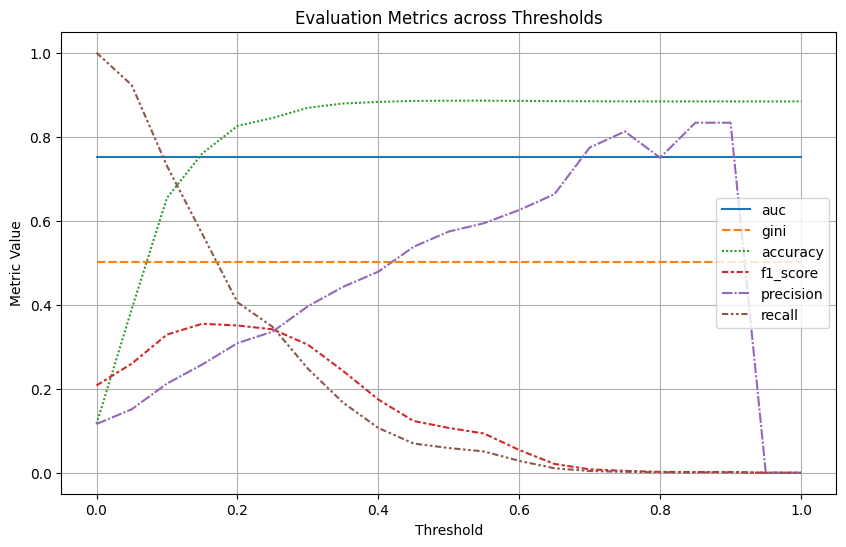

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the threshold column as the index so it becomes the X-axis
df_plot = final_scan_df.set_index('threshold')

plt.figure(figsize=(10, 6))

# Plot all columns ('auc', 'gini', 'accuracy', etc.) at once
sns.lineplot(data=df_plot)

plt.title('Evaluation Metrics across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.grid(True)
plt.show()

In [19]:
final_scan_df

,threshold,auc,gini,accuracy,f1_score,precision,recall
0,0.00,0.750531,0.501062,0.115958,0.207819,0.115958,1.000000
1,0.05,0.750531,0.501062,0.389622,0.259643,0.151070,0.922999
2,0.10,0.750531,0.501062,0.654278,0.328873,0.212204,0.730496
3,0.15,0.750531,0.501062,0.759937,0.354669,0.257648,0.568896
4,0.20,0.750531,0.501062,0.825612,0.350591,0.308522,0.405944
5,0.25,0.750531,0.501062,0.844723,0.341472,0.335948,0.347180
6,0.30,0.750531,0.501062,0.868964,0.304944,0.396114,0.247889
7,0.35,0.750531,0.501062,0.879029,0.242335,0.442652,0.166836
8,0.40,0.750531,0.501062,0.882945,0.174309,0.478756,0.106552
9,0.45,0.750531,0.501062,0.885177,0.123206,0.537859,0.069571


## 2. Quantitative Trade-off: Total Predicted Interest vs. Approval Threshold
To find the optimal operational strategy, we model the portfolio's financial return by defining **Total Predicted Interest** as a function of our decision threshold ($t$). 

When we adjust the threshold $t$, we change the decision rule: any borrower with a predicted default probability *less than or equal to* $t$ is approved.

In [73]:
# Loan profit
interest = 0.01

test_df['LoanInterest'] = (test_df['LoanAmount'] * (1 + interest) ** test_df['LoanTerm']).astype(int) - test_df['LoanAmount']
test_df[['LoanAmount','LoanTerm','LoanInterest']]

growthVsRisk = pandas.DataFrame(columns=['threshold', 'totalLoanAmount', 'totalLoanInterest', 'actualDefaultAmount', 'predictedNotWithinActualInterest', 'PredictedWithinActualAmount'])

for threshold in [x / 100 for x in range(0, 101, 5)]:
    y_pred = (y_proba >= threshold).astype(bool)
    growthVsRisk.loc[len(growthVsRisk)] = {
        'threshold': threshold,
        'totalLoanAmount': test_df['LoanAmount'].sum(),
        'totalLoanInterest': test_df['LoanInterest'].sum(),
        'actualDefaultAmount': test_df[y_test.astype(bool)]['LoanAmount'].sum(),
        'predictedNotWithinActualInterest': test_df[y_pred & ~y_test.astype(bool)]['LoanInterest'].sum(),
        'PredictedWithinActualAmount': test_df[y_test.astype(bool) & y_pred]['LoanAmount'].sum()
    }

growthVsRisk['totalPredictedInterest'] = growthVsRisk['PredictedWithinActualAmount'] - growthVsRisk['predictedNotWithinActualInterest']
# growthVsRisk['PredictedFraction'] = growthVsRisk['predictedDefaultAmount'] / growthVsRisk['totalLoanInterest']
# growthVsRisk['PredictedWithinActualFraction'] = growthVsRisk['PredictedWithinActual'] / growthVsRisk['totalLoanInterest']
# growthVsRisk['predictedDefaultInterestFraction'] = growthVsRisk['predictedDefaultInterest'] / growthVsRisk['totalLoanAmount']

growthVsRisk

,threshold,totalLoanAmount,totalLoanInterest,actualDefaultAmount,predictedNotWithinActualInterest,PredictedWithinActualAmount,totalPredictedInterest
0,0.00,6509277454,2931805064,844742953,2555927102,844742953,-1711184149
1,0.05,6509277454,2931805064,844742953,1886210105,797050193,-1089159912
2,0.10,6509277454,2931805064,844742953,1049365293,657267358,-392097935
3,0.15,6509277454,2931805064,844742953,659566382,529893954,-129672428
4,0.20,6509277454,2931805064,844742953,383816728,393548578,9731850
5,0.25,6509277454,2931805064,844742953,291271871,338254168,46982297
6,0.30,6509277454,2931805064,844742953,164808094,249057359,84249265
7,0.35,6509277454,2931805064,844742953,94151371,171905483,77754112
8,0.40,6509277454,2931805064,844742953,52391616,112110432,59718816
9,0.45,6509277454,2931805064,844742953,27804613,76555841,48751228


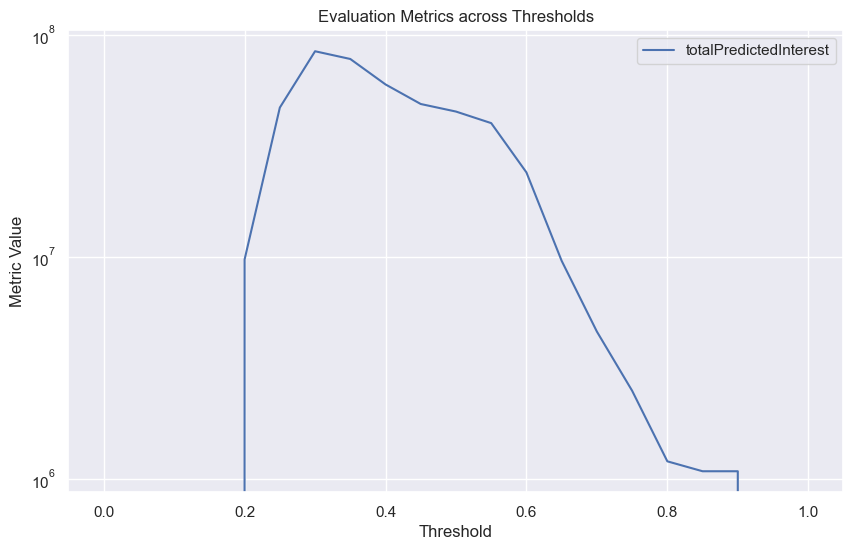

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the threshold column as the index so it becomes the X-axis
df_plot = growthVsRisk.set_index('threshold')

plt.figure(figsize=(10, 6))

# Plot all columns ('auc', 'gini', 'accuracy', etc.) at once
grid = sns.lineplot(data=df_plot[['totalPredictedInterest']])
grid.set(yscale="log")

plt.title('Evaluation Metrics across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.grid(True)
plt.show()

### Strategic Verdict: Optimal Threshold Selection
Our graphical and quantitative analysis reveals that the portfolio's net financial return is maximized at a decision threshold of **0.35**. 

#### Core Takeaways:
* **The Profitability Peak:** At $t = 0.35$, the Total Predicted Interest function reaches its absolute mathematical apex. Setting the cut-off here ensures we capture the maximum possible interest revenue while successfully filtering out the highly toxic loans that drag down profitability.
* **Balanced Growth and Risk:** Approving applicants with a predicted default probability of up to 35% allows the institution to expand its market share safely. Beyond this 0.35 tipping point, the marginal revenue gained from new approvals is sharply erased by the compounding costs of actual defaults.
* **Operational Recommendation:** We recommend deploying this 0.35 threshold into the production credit-scoring engine. This operational mandate provides the risk and growth teams with a concrete, data-backed boundary to maximize net portfolio returns without exposing capital to unacceptable default rates.